In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report,roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBClassifier
import warnings
from sklearn.naive_bayes import GaussianNB

In [2]:
from sklearn.preprocessing import LabelEncoder

### Dataset loading and analysing

In [3]:
df = pd.read_csv('Beans_data.csv')
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [4]:
df.columns

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4', 'Class'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

here from the above code we could see that there is no null values in either of the variables

### EDA and data cleaning

In [6]:
df.isna().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

In [7]:
df.shape

(13611, 17)

In [8]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


Now we are going to plot a chart on the data

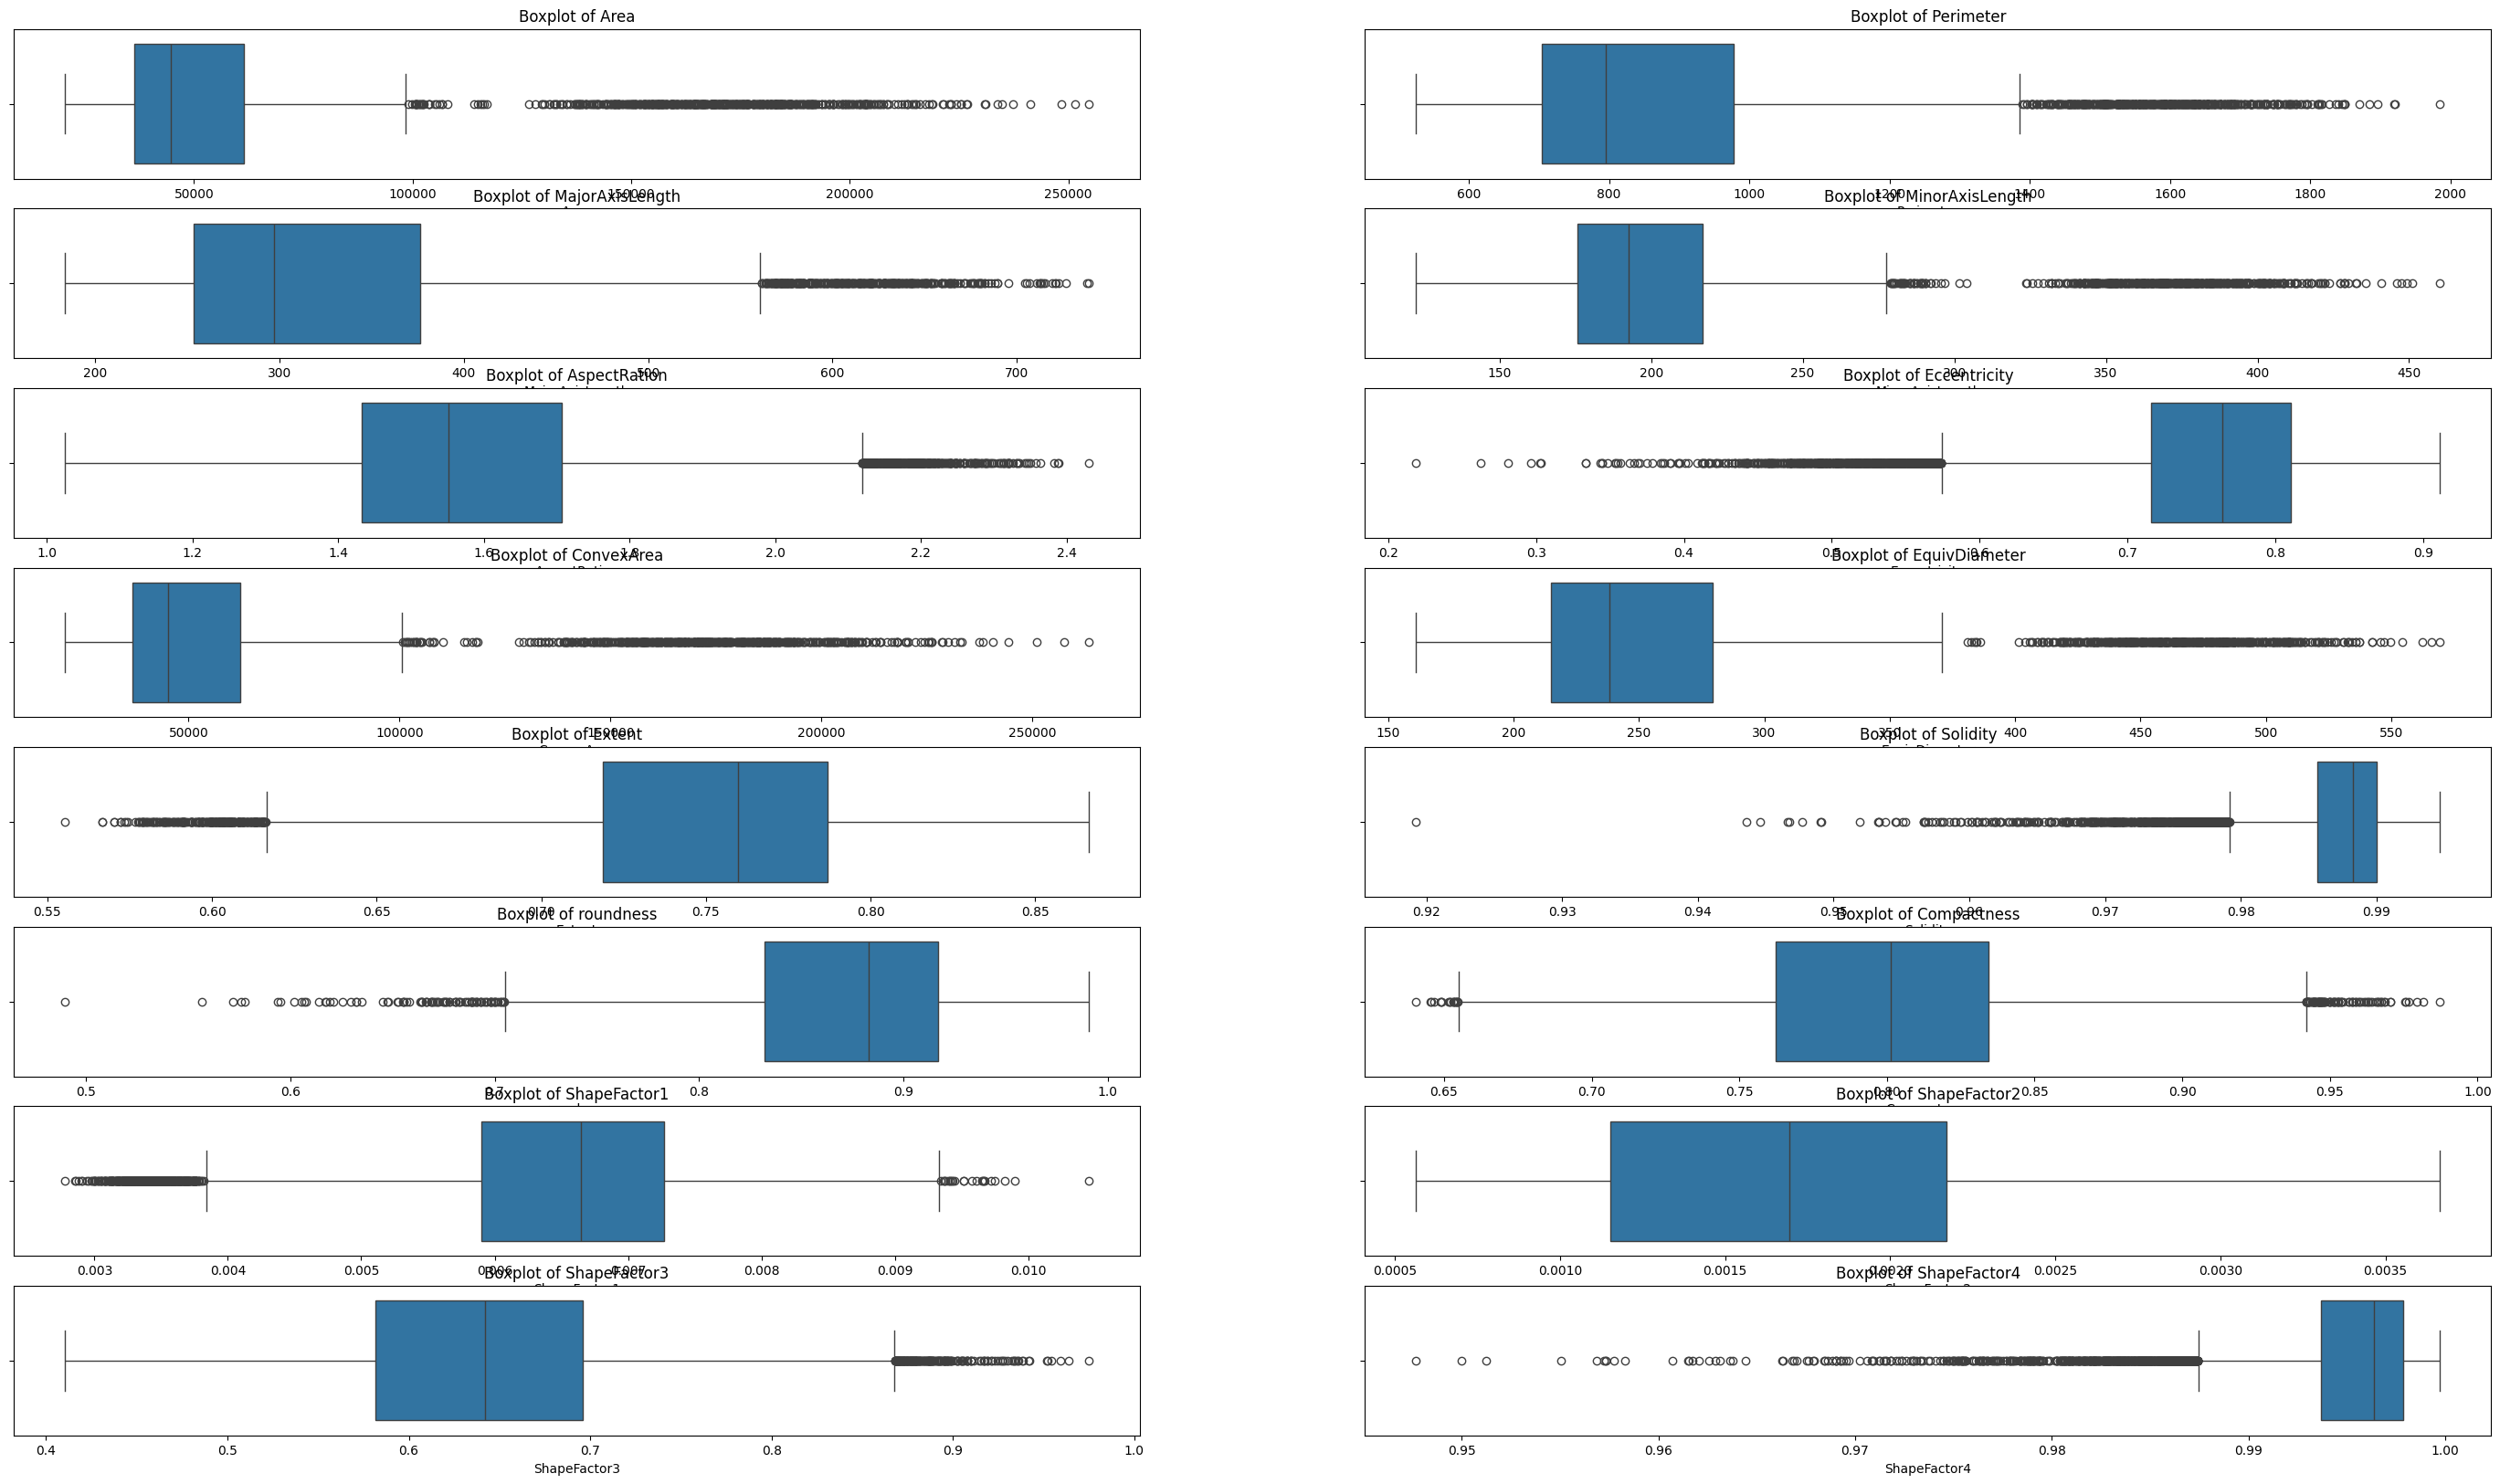

In [9]:
features = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']

# Create a 2x2 axis matrix
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(35, 20))

# Flatten axes matrix into a 1D array for easy iteration
axes = axes.flatten()

for i,features in enumerate(features):
    sns.boxplot(x=df[features], ax=axes[i])
    axes[i].set_title(f'Boxplot of {features}')

Text(0.5, 1.0, 'Boxplot of Area by Class')

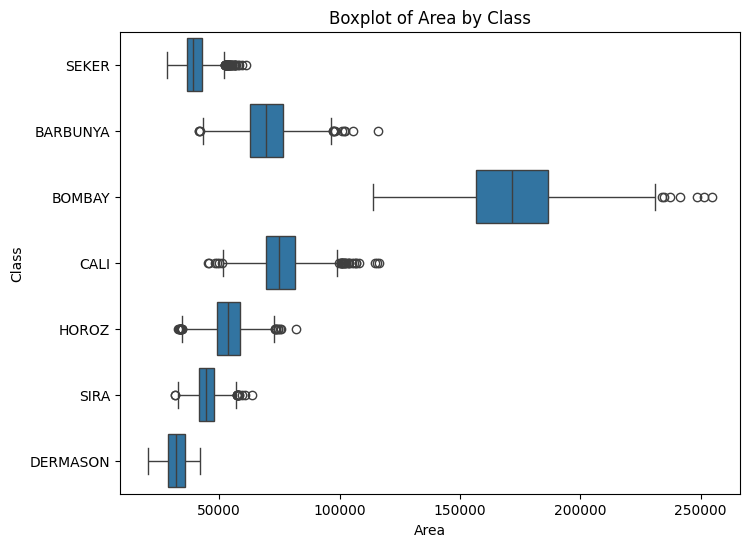

In [10]:
plt.figure(figsize=(8, 6))
sns.boxplot(x = df['Area'], y = df['Class'])
plt.title('Boxplot of Area by Class')

Text(0.5, 1.0, 'Class Distribution')

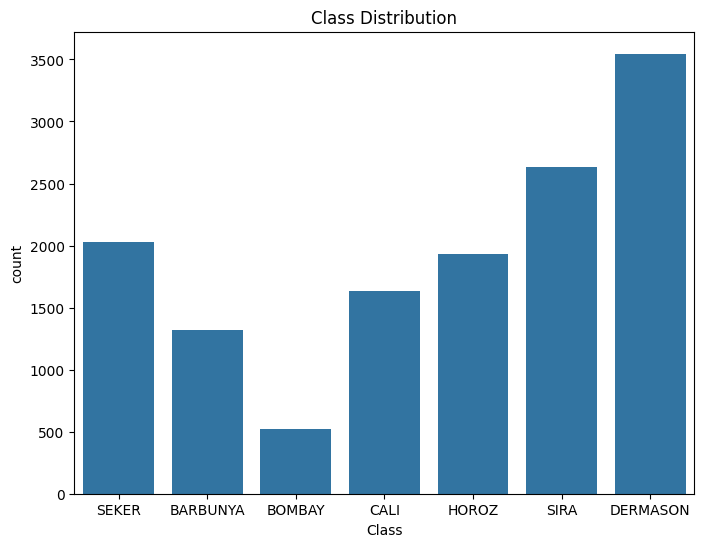

In [11]:
# let's check the class distribution of the data by histogram
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')

In [4]:
le = LabelEncoder()
df['target_encoded'] = le.fit_transform(df['Class'])

In [13]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class,target_encoded
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER,5
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER,5
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER,5
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER,5
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER,5


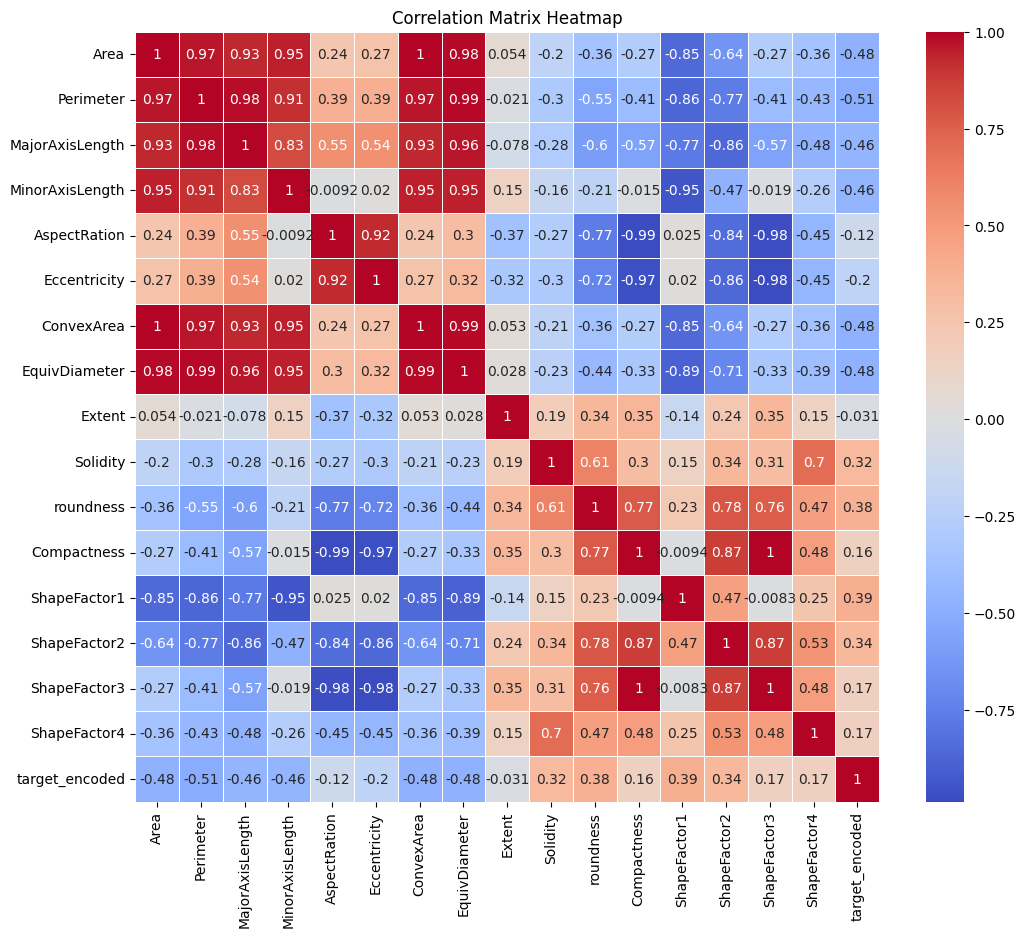

In [14]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap') 
plt.show()

here you could see that there high multicolinearity on this make it confirm that it really has multicolinearity we will use VIF on this detect it

In [15]:
# code for vairnce inflation factor
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Select numerical features for VIF calculation
X = df.select_dtypes(include = ['int64', 'float64'])

#Create a DataFrame to store VIF values
vif_data = pd.DataFrame()
vif_data['features'] = X.columns

vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

vif_data = vif_data.sort_values(by="VIF", ascending=False)
print(vif_data)

           features           VIF
7     EquivDiameter  6.091322e+06
15     ShapeFactor4  3.093217e+06
11      Compactness  2.663418e+06
3   MinorAxisLength  1.645683e+06
2   MajorAxisLength  1.314375e+06
9          Solidity  6.267557e+05
14     ShapeFactor3  5.837521e+05
0              Area  3.461903e+05
6        ConvexArea  3.320131e+05
4      AspectRation  1.699956e+05
1         Perimeter  6.098239e+04
5      Eccentricity  2.405223e+04
12     ShapeFactor1  2.272932e+04
10        roundness  2.251379e+04
13     ShapeFactor2  1.150570e+04
8            Extent  2.916007e+02
16   target_encoded  1.125000e+01


In [16]:
vif_data

,features,VIF
7,EquivDiameter,6.091322e+06
15,ShapeFactor4,3.093217e+06
11,Compactness,2.663418e+06
3,MinorAxisLength,1.645683e+06
2,MajorAxisLength,1.314375e+06
9,Solidity,6.267557e+05
14,ShapeFactor3,5.837521e+05
0,Area,3.461903e+05
6,ConvexArea,3.320131e+05
4,AspectRation,1.699956e+05


Text(0.5, 1.0, 'Correlation Matrix Heatmap')

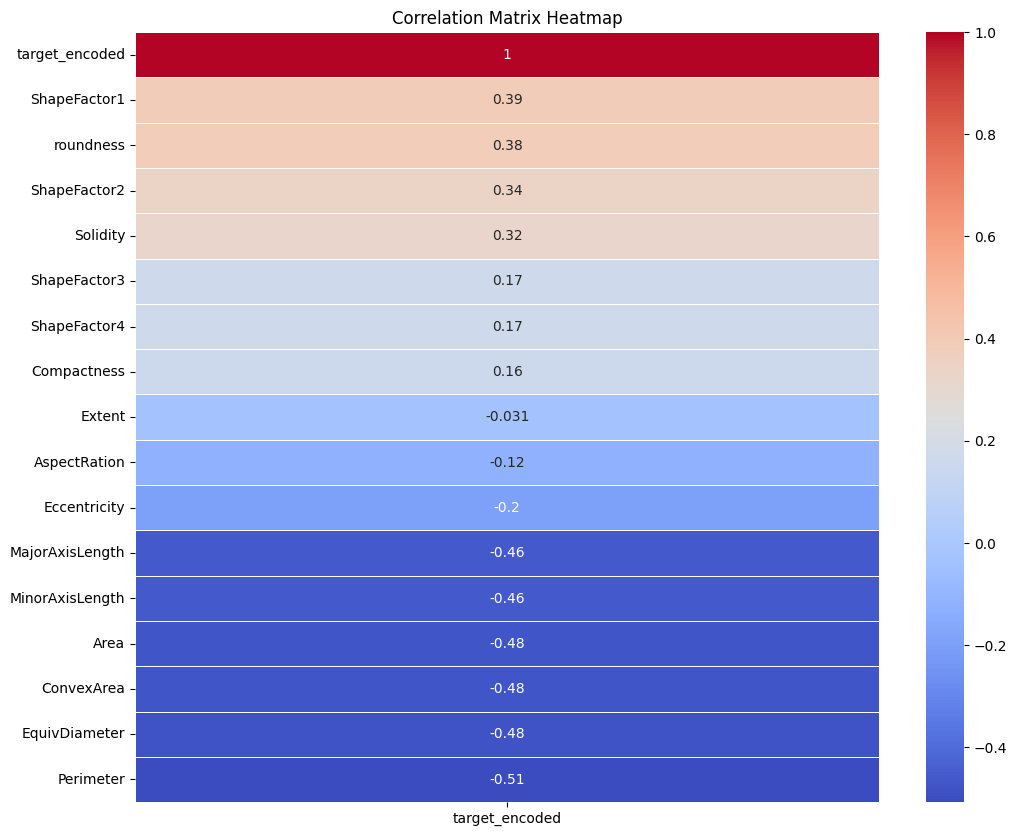

In [17]:
correlation_matrix = df.corr(numeric_only=True)[['target_encoded']].sort_values(by='target_encoded',ascending=False)
plt.figure(figsize=(12, 10))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap') 

In [18]:
# let's find the value of the data with different models with outlier data
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier()
    }


In [4]:
model_results = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'])

In [5]:
# split the data into training and testing sets

X = df.drop(columns=['Class', 'target_encoded'])
y = df['target_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [7]:
# here we scale the data with standard scaler and min max scaler
standard_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()
X_train_scaled_standard = standard_scaler.fit_transform(X_train)
X_test_scaled_standard = standard_scaler.transform(X_test)
X_train_scaled_minmax = min_max_scaler.fit_transform(X_train)
X_test_scaled_minmax = min_max_scaler.transform(X_test)


In [22]:
def evaluate_model(model, X, y):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train_scaled_standard = standard_scaler.fit_transform(X_train)
    X_test_scaled_standard = standard_scaler.transform(X_test)
    model.fit(X_train_scaled_standard, y_train)
    y_pred = model.predict(X_test_scaled_standard)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled_standard), multi_class='ovo')
    print(f"{model.__class__.__name__}:\n Accuracy: {accuracy}, Precision: {precision}, Recall: {recall}, F1: {f1}, ROC AUC: {roc_auc}")

In [23]:
#by Random Forest
evaluate_model(RandomForestClassifier(), X_test_scaled_standard, y_test)

RandomForestClassifier:
 Accuracy: 0.9064220183486239, Precision: 0.9083817456992286, Recall: 0.9064220183486239, F1: 0.9060325419692464, ROC AUC: 0.9924361612637171


In [24]:
# By Logistic Regression 
evaluate_model(LogisticRegression(), X_test_scaled_standard, y_test)

LogisticRegression:
 Accuracy: 0.926605504587156, Precision: 0.9269790400425534, Recall: 0.926605504587156, F1: 0.9264994963002277, ROC AUC: 0.9962789363904883


here we could see that model is giving 92.65 % on the data i.e. having too outliers \
Now lets see on the data after removing the outliers from the data

In [25]:
# now we are going to remove the outlier data and check the value of the data with different models
# here we first which features has the lowest outlier data and we will remove the outlier data from the table

for i in X.columns:
    iqr = df[i].quantile(0.75) - df[i].quantile(0.25)
    lower_bound = df[i].quantile(0.25) - 1.5 * iqr
    upper_bound = df[i].quantile(0.75) + 1.5 * iqr
    print(f"feature: {i},  number of outliers: {df[(df[i]<lower_bound) | (df[i]>upper_bound)].shape[0]}")

feature: Area,  number of outliers: 551
feature: Perimeter,  number of outliers: 500
feature: MajorAxisLength,  number of outliers: 379
feature: MinorAxisLength,  number of outliers: 569
feature: AspectRation,  number of outliers: 473
feature: Eccentricity,  number of outliers: 843
feature: ConvexArea,  number of outliers: 550
feature: EquivDiameter,  number of outliers: 526
feature: Extent,  number of outliers: 275
feature: Solidity,  number of outliers: 778
feature: roundness,  number of outliers: 91
feature: Compactness,  number of outliers: 109
feature: ShapeFactor1,  number of outliers: 533
feature: ShapeFactor2,  number of outliers: 0
feature: ShapeFactor3,  number of outliers: 195
feature: ShapeFactor4,  number of outliers: 767


here we could see that max number of outliers are 843 of Eccentricity, we will remove those data that has more lower and the upper bound of the data

In [26]:
iqr = df['Eccentricity'].quantile(0.75) - df['Eccentricity'].quantile(0.25)
lower_bound = df['Eccentricity'].quantile(0.25) - 1.5 * iqr
upper_bound = df['Eccentricity'].quantile(0.75) + 1.5 * iqr
filtered_df = df[(df['Eccentricity'] >= lower_bound) & (df['Eccentricity'] <= upper_bound)]


Now let's whether the model gives good performance or not

In [27]:
X = filtered_df.drop(columns=['Class', 'target_encoded'])
y = filtered_df['target_encoded']
evaluate_model(LogisticRegression(),X, y)
evaluate_model(DecisionTreeClassifier(),X, y)
evaluate_model(RandomForestClassifier(),X, y)
evaluate_model(SVC(probability=True),X, y)
evaluate_model(GaussianNB(),X, y)
evaluate_model(KNeighborsClassifier(),X, y)
evaluate_model(XGBClassifier(),X, y)

LogisticRegression:
 Accuracy: 0.9240407204385278, Precision: 0.9258791191865173, Recall: 0.9240407204385278, F1: 0.924567724448213, ROC AUC: 0.9954556528057222
DecisionTreeClassifier:
 Accuracy: 0.8841033672670321, Precision: 0.8846249188495012, Recall: 0.8841033672670321, F1: 0.8840790680188502, ROC AUC: 0.9407822655269009
RandomForestClassifier:
 Accuracy: 0.9193422083007048, Precision: 0.9203354532980313, Recall: 0.9193422083007048, F1: 0.9195915105240887, ROC AUC: 0.994106242607384
SVC:
 Accuracy: 0.9283476898981989, Precision: 0.9296782047424771, Recall: 0.9283476898981989, F1: 0.9287334788690668, ROC AUC: 0.9958371188133978
GaussianNB:
 Accuracy: 0.889584964761159, Precision: 0.8921873865063761, Recall: 0.889584964761159, F1: 0.8901292006308308, ROC AUC: 0.9912092144537322
KNeighborsClassifier:
 Accuracy: 0.9212999216914644, Precision: 0.9222815910014421, Recall: 0.9212999216914644, F1: 0.9216292868081429, ROC AUC: 0.9861392045991422
XGBClassifier:
 Accuracy: 0.9271730618637432,

As we could see in the above model even though we remove the outliers from the data we still have similar ROC AUC in the data so it's better we should not remove the outliers from the data 

Now lets use GridSearchCV and RandomSearchCV to find which parameters suits or we could say the hyperparameters that suits good with it

In [8]:
# split the data into training and testing sets

X = df.drop(columns=['Class', 'target_encoded'])
y = df['target_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled = standard_scaler.fit_transform(X_train)
X_test_scaled = standard_scaler.transform(X_test)

In [11]:
# let's do the best parameters for Support Vector Classifier (SVC) model using GridSearchCV
parms = {
    'C' :  [0.1, 1, 10, 100],
    'kernel' : ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma' : ['scale', 'auto']
}

model = SVC()

grid = GridSearchCV(model, parms, cv=5, n_jobs=-1)
grid.fit(X_train_scaled, y_train)
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)
print("Test score:", grid.score(X_test_scaled, y_test))

Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV score: 0.9304741151861876
Test score: 0.9346309217774513


In [34]:
#let's find the best parameters for Logistic regression model using Grid Search CV
logreg = LogisticRegression(max_iter=1000)

logparms = {
    'C': [0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['lbfgs', 'liblinear']
}

log_grid = GridSearchCV(logreg, logparms, cv=5, n_jobs=-1)
log_grid.fit(X_train_scaled, y_train)
print("Best params:", log_grid.best_params_)
print("Best CV score:", log_grid.best_score_)
print("Test_score:", log_grid.score(X_test_scaled, y_test))

d:\ML_deployment\myenv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
20 fits failed out of a total of 80.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "d:\ML_deployment\myenv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\ML_deployment\myenv\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "d:\ML_deployment\myenv\lib\site-packages\sklearn\linear_model\_logistic.py", line 1218, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File 

Best params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV score: 0.9245040288887119
Test_score: 0.9265515975027543


In [31]:
#let's find the best parmeters for random forest calssifier model using GrisdSearchCV
rf = RandomForestClassifier(random_state=42)

ranparms = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['auto', 'sqrt', 'log2']
}

rf_grid = GridSearchCV(rf, ranparms, cv=5, n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)
print("Best params:", rf_grid.best_params_)
print("Best CV score:", rf_grid.best_score_)
print('Test score:', rf_grid.score(X_test_scaled, y_test))

d:\ML_deployment\myenv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
180 fits failed out of a total of 540.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
160 fits failed with the following error:
Traceback (most recent call last):
  File "d:\ML_deployment\myenv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\ML_deployment\myenv\lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "d:\ML_deployment\myenv\lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_parameter_constraints(
  File "d:\ML_deployment\myenv\lib\site-packages\sklearn

Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 50}
Best CV score: 0.9233100622460458
Test score: 0.9203084832904884


In [32]:
#let's find the best parameters for K Nearest Neighbors model using GridSearchCV

Knn = KNeighborsClassifier()

Knn_parms = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
grid_knn = GridSearchCV(Knn, Knn_parms, cv=5, n_jobs=-1)

grid_knn.fit(X_train_scaled, y_train)
print("Best params:", grid_knn.best_params_)
print("Best CV score:", grid_knn.best_score_)
print("Test score:", grid_knn.score(X_test_scaled, y_test))

Best params: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Best CV score: 0.9241372255987865
Test score: 0.9254498714652957


In [33]:
#Let's find the best parameters for Decision Tree Classifier using GridSearchCV
dt = DecisionTreeClassifier(random_state=42)

dt_params = {
    'criterion': ['gini','entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['auto', 'sqrt', 'log2'],
    'min_samples_leaf': [1, 2, 4]
    }

grid_dt = GridSearchCV(dt, dt_params, cv=5, n_jobs=-1)
grid_dt.fit(X_train_scaled, y_train)
print("Best params:", grid_dt.best_params_)
print('Best CV Score:', grid_dt.best_score_)
print("Test Score:", grid_dt.score(X_test_scaled, y_test))

d:\ML_deployment\myenv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
360 fits failed out of a total of 1080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
200 fits failed with the following error:
Traceback (most recent call last):
  File "d:\ML_deployment\myenv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\ML_deployment\myenv\lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "d:\ML_deployment\myenv\lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_parameter_constraints(
  File "d:\ML_deployment\myenv\lib\site-packages\sklear

Best params: {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV Score: 0.9029200848844228
Test Score: 0.9048843187660668


In [ ]:
#let's find the best parameters for Bagging Classifier using GridSearchCV
Bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42)

bag_parms = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.5, 0.7, 1.0],
    'max_features': [0.5, 0.6, 0.8, 1.0]
}

bag_grid = GridSearchCV(Bag, bag_parms, cv = 5, n_jobs=-1)
bag_grid.fit(X_train_scaled, y_train)
print('Best Params:', bag_grid.best_params_)
print('Best CV Score:', bag_grid.best_score_)
print('Test Score:', bag_grid.score(X_test_scaled, y_test))

Best Params: {'max_features': 1.0, 'max_samples': 1.0, 'n_estimators': 100}
Best CV Score: 0.9250551196181129
Test Score: 0.9239809034153507


In [14]:
xg  = XGBClassifier(random_state =42)

xgb_param_grid = {
    'max_depth': [3, 5, 7],                    
    'learning_rate': [0.05, 0.1],              
    'n_estimators': [50, 100, 150, 200],       
    'subsample': [0.8, 1.0]                    
}

xgb_grid = GridSearchCV(xg, xgb_param_grid, cv = 5, n_jobs = -1, scoring = 'accuracy')
xgb_grid.fit(X_train_scaled, y_train)
print('Best Params:', xgb_grid.best_params_)
print('Best CV score:', xgb_grid.best_score_)
print('Test Score:', xgb_grid.score(X_test_scaled, y_test))

Best Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 150, 'subsample': 0.8}
Best CV score: 0.9294639298147043
Test Score: 0.9302240176276166


In [9]:
# Now let's compare all the model and let's find which model fits better

def compare_classification_models(models_dict, X_train, X_test,y_train, y_test):
    results = []

    for name, model in models_dict.items():
        print(f'\nTraining {name}:')

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        try:
            y_proba = model.predict_proba(X_test)
            # For binary classification, use probability of class 1
            if y_proba.shape[1] == 2:
                y_proba_class1 = y_proba[:, 1]
            else:
                # For multiclass, use average of all classes
                y_proba_class1 = y_proba
        except:
            # Some models don't support predict_proba
            y_proba_class1 = Noney_proba = model
        
        #calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')

        #calculate ROC-AUC curve
        if y_proba_class1 is not None:
            try:
                roc_auc = roc_auc_score(y_test, y_proba_class1, average='weighted', multi_class='ovo')
            except:
                roc_auc = roc_auc_score(y_test, y_proba_class1)
        else:
            roc_auc = None
        print(f"  Accuracy:  {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  ROC-AUC:   {roc_auc}")

        results.append({
            'Model': name,
            'Accuracy': round(accuracy, 4),
            'Precision': round(precision, 4),
            'Recall': round(recall, 4),
            'ROC-AUC': round(roc_auc, 4)
        })
    
    # Create DataFrame
    comparison_df = pd.DataFrame(results)
    
    
    
    # Round all values to 4 decimal places
    comparison_df['Accuracy'] = comparison_df['Accuracy'].round(4)
    comparison_df['Precision'] = comparison_df['Precision'].round(4)
    comparison_df['Recall'] = comparison_df['Recall'].round(4)
    comparison_df['ROC-AUC'] = comparison_df['ROC-AUC'].round(4)
    
    # Sort by ROC-AUC (best performing first)
    comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)
    
    print(comparison_df.to_string(index=False))
    
    return comparison_df

In [14]:
models_dict = {
'XGBoost Classifier': XGBClassifier(learning_rate = 0.05, max_depth = 5, n_estimators = 150, subsample = 0.8),
'Bagging Classifier': BaggingClassifier(max_features = 1.0, max_samples = 1.0, n_estimators=100),
'Decision Tree Classifier': DecisionTreeClassifier(criterion= 'gini', max_depth=10, max_features='sqrt', min_samples_leaf=4, min_samples_split=10),
'K Neighbors Classifier': KNeighborsClassifier(metric='euclidean', n_neighbors= 9, weights = 'distance'),
'Random Forest Classifier': RandomForestClassifier(max_depth = 20, max_features = 'sqrt', min_samples_split = 5, n_estimators =  50),
'Logistic Regression': LogisticRegression(),
'SVC': SVC(probability= True,C = 10, gamma  = 'scale', kernel='rbf')
}

In [15]:
comparision_df = compare_classification_models(models_dict = models_dict,
                                               X_train  = X_train_scaled,
                                               X_test= X_test_scaled,
                                               y_train = y_train,
                                               y_test = y_test)

comparision_df


Training XGBoost Classifier:
  Accuracy:  0.9321
  Precision: 0.9325
  Recall:    0.9321
  ROC-AUC:   0.9956750059488706

Training Bagging Classifier:
  Accuracy:  0.9251
  Precision: 0.9254
  Recall:    0.9251
  ROC-AUC:   0.9926509942697991

Training Decision Tree Classifier:
  Accuracy:  0.8961
  Precision: 0.8971
  Recall:    0.8961
  ROC-AUC:   0.9818416873904905

Training K Neighbors Classifier:
  Accuracy:  0.9254
  Precision: 0.9266
  Recall:    0.9254
  ROC-AUC:   0.989482799169059

Training Random Forest Classifier:
  Accuracy:  0.9254
  Precision: 0.9261
  Recall:    0.9254
  ROC-AUC:   0.9943046794021281

Training Logistic Regression:
  Accuracy:  0.9266
  Precision: 0.9278
  Recall:    0.9266
  ROC-AUC:   0.9951395429001061

Training SVC:
  Accuracy:  0.9346
  Precision: 0.9351
  Recall:    0.9346
  ROC-AUC:   0.9957648477321966
                   Model  Accuracy  Precision  Recall  ROC-AUC
                     SVC    0.9346     0.9351  0.9346   0.9958
      XGBoost Class

,Model,Accuracy,Precision,Recall,ROC-AUC
6,SVC,0.9346,0.9351,0.9346,0.9958
0,XGBoost Classifier,0.9321,0.9325,0.9321,0.9957
5,Logistic Regression,0.9266,0.9278,0.9266,0.9951
4,Random Forest Classifier,0.9254,0.9261,0.9254,0.9943
1,Bagging Classifier,0.9251,0.9254,0.9251,0.9927
3,K Neighbors Classifier,0.9254,0.9266,0.9254,0.9895
2,Decision Tree Classifier,0.8961,0.8971,0.8961,0.9818


As you could see that Support Vector Classifier suits the best amoung all the model, followed by XGBoost CLassifier, Logistic Regression, Random Forest Classifier, Bagging Classifier, KNN CLassifer and Decision Tree

Now we are going to deploy make model in the form of pipline and them dump it into job lib format

In [18]:
pipeline = Pipeline([
    ('scalar', StandardScaler()),
    ('svc',SVC(probability= True,C = 10, gamma  = 'scale', kernel='rbf')),

])

In [ ]:
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

predicted_class = le.inverse_transform(y_pred)
print(predicted_class[:10])



['SEKER' 'BARBUNYA' 'SEKER' 'SEKER' 'DERMASON' 'SEKER' 'CALI' 'SEKER'
 'BOMBAY' 'DERMASON']


In [22]:
accuracy = accuracy_score(y_pred, y_test)

In [20]:
import joblib

joblib.dump(pipeline, 'svc_pipeline.pkl')
joblib.dump(le, 'label_encoder.pkl')


['label_encoder.pkl']

In [23]:
print(accuracy)

0.9346309217774513


In [21]:
pipeline.feature_names_in_

array(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter',
       'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1',
       'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4'], dtype=object)